# Оценка моделей после Optuna

Ноутбук загружает признаки и Optuna-модели, оценивает их на тестовой выборке, выполняет кросс-валидацию, оптимизацию порога и калибровку вероятностей.

## Импорты и загрузка данных

In [1]:
import os
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from scipy.sparse import hstack

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.models.classical import (
    NUMERICAL_COLUMNS,
    prepare_features,
    train_classical_models,
    predict_message,
    save_models,
)
from src.evaluation.metrics import optimize_threshold
from src.config import PROCESSED_DIR, MODELS_DIR, INTERIM_DIR

import optuna
import lightgbm
import catboost
import nltk

nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings(
    'ignore',
    message='X does not have valid feature names',
    category=UserWarning,
    module='sklearn.utils.validation',
)
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [2]:
with open(INTERIM_DIR / 'features_train.pkl', 'rb') as f:
    train_data = pickle.load(f)
X_train = train_data['X_train']
X_train_nc = train_data['X_train_nc']
y_train = train_data['y_train']

with open(INTERIM_DIR / 'features_test.pkl', 'rb') as f:
    test_data = pickle.load(f)
X_test = test_data['X_test']
X_test_nc = test_data['X_test_nc']
y_test = test_data['y_test']

with open(INTERIM_DIR / 'base_models.pkl', 'rb') as f:
    base_models = pickle.load(f)

with open(INTERIM_DIR / 'optuna_models.pkl', 'rb') as f:
    optuna_data = pickle.load(f)
optuna_results = optuna_data['models']

y_test_arr = np.array(y_test)
print(f'Загружено моделей: {len(optuna_results)}')
print(f'Модели: {list(optuna_results.keys())}')

Загружено моделей: 5
Модели: ['lr', 'lgbm', 'catboost', 'rf', 'nb']


Функция для вычисления метрик на тестовой выборке.

In [3]:
def evaluate_on_test(models, X_test, y_test, X_test_nc=None, prefix='base'):
    """Вычисляет метрики для каждой модели на тестовой выборке."""
    results = []
    for name, model in models.items():
        X_eval = X_test_nc if name == 'nb' and X_test_nc is not None else X_test
        y_pred = model.predict(X_eval)
        y_proba = model.predict_proba(X_eval)[:, 1]

        results.append({
            'model': f'{prefix}_{name}',
            'accuracy': float((y_pred == y_test).mean()),
            'precision_spam': float(precision_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'recall_spam': float(recall_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'f1_spam': float(f1_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'f1_macro': float(f1_score(y_test, y_pred, average='macro', zero_division=0)),
            'roc_auc': float(roc_auc_score(y_test, y_proba)),
            'pr_auc': float(average_precision_score(y_test, y_proba)),
        })
    return pd.DataFrame(results)

## Оценка на тестовой выборке

Сравнение базовых моделей и моделей после Optuna.

In [4]:
base_results = evaluate_on_test(base_models, X_test, y_test_arr, X_test_nc, prefix='base')
optuna_results_df = evaluate_on_test(optuna_results, X_test, y_test_arr, X_test_nc, prefix='optuna')
all_results = pd.concat([base_results, optuna_results_df], ignore_index=True)
all_results = all_results.sort_values('f1_macro', ascending=False).reset_index(drop=True)
all_results

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,roc_auc,pr_auc
0,optuna_lr,0.961154,0.989601,0.923976,0.955663,0.960549,0.986729,0.988041
1,base_lr,0.960091,0.990417,0.920828,0.954356,0.959451,0.990388,0.990554
2,base_rf,0.956272,0.992497,0.910371,0.949662,0.955504,0.977944,0.982914
3,optuna_lgbm,0.954700,0.989894,0.909304,0.947889,0.953913,0.980754,0.984131
4,base_lgbm,0.954144,0.991596,0.906477,0.947128,0.953322,0.980168,0.983795
5,optuna_catboost,0.950712,0.990775,0.899595,0.942986,0.949790,0.969524,0.977747
6,base_catboost,0.948996,0.991084,0.895487,0.940863,0.948012,0.971332,0.978399
7,optuna_rf,0.946409,0.987666,0.892872,0.937880,0.945379,0.983847,0.985129
8,optuna_nb,0.868863,0.987055,0.720017,0.832650,0.862421,0.958776,0.962553
9,base_nb,0.856390,0.985809,0.693022,0.813884,0.848487,0.950470,0.955724


## Classification reports

Подробные отчёты классификации для каждой модели после Optuna.

In [5]:
for name, model in optuna_results.items():
    X_eval = X_test_nc if name == 'nb' else X_test
    y_pred = model.predict(X_eval)
    print(f'optuna_{name}')
    print(classification_report(y_test_arr, y_pred, target_names=['Ham', 'Spam']))
    print()

optuna_lr
              precision    recall  f1-score   support

         Ham       0.94      0.99      0.97     22625
        Spam       0.99      0.92      0.96     18744

    accuracy                           0.96     41369
   macro avg       0.96      0.96      0.96     41369
weighted avg       0.96      0.96      0.96     41369


optuna_lgbm
              precision    recall  f1-score   support

         Ham       0.93      0.99      0.96     22625
        Spam       0.99      0.91      0.95     18744

    accuracy                           0.95     41369
   macro avg       0.96      0.95      0.95     41369
weighted avg       0.96      0.95      0.95     41369


optuna_catboost
              precision    recall  f1-score   support

         Ham       0.92      0.99      0.96     22625
        Spam       0.99      0.90      0.94     18744

    accuracy                           0.95     41369
   macro avg       0.96      0.95      0.95     41369
weighted avg       0.95      0.95 

## Confusion matrices

Матрицы ошибок для всех моделей после Optuna.

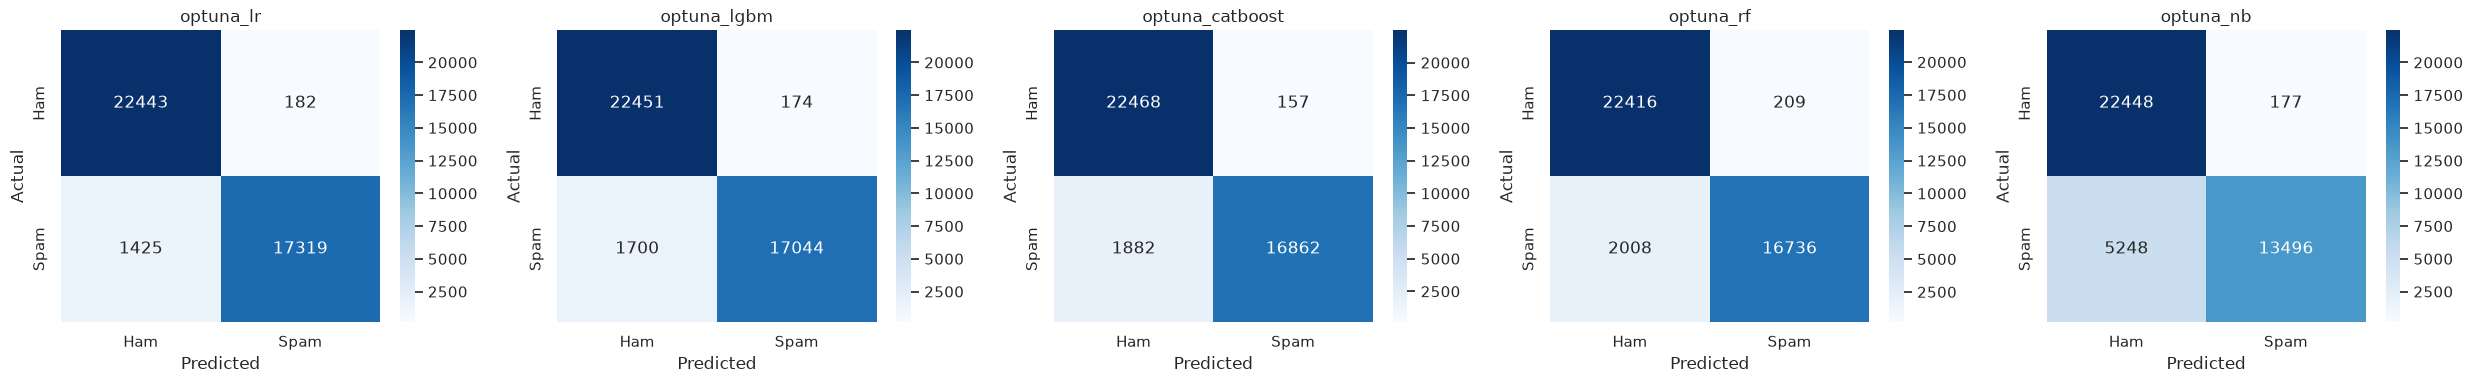

In [6]:
fig, axes = plt.subplots(1, len(optuna_results), figsize=(5 * len(optuna_results), 4))
if len(optuna_results) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, optuna_results.items()):
    X_eval = X_test_nc if name == 'nb' else X_test
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test_arr, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(f'optuna_{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Кросс-валидация (5-fold)

Stratified 5-fold CV на обучающей выборке для оценки устойчивости моделей.

In [7]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in optuna_results.items():
    X_eval = X_train_nc if name == 'nb' else X_train
    f1_scores = cross_val_score(model, X_eval, y_train, cv=cv5, scoring='f1_macro', n_jobs=-1)
    cv_results.append({
        'model': f'optuna_{name}',
        'f1_macro_mean': float(f1_scores.mean()),
        'f1_macro_std': float(f1_scores.std()),
    })

cv_df = pd.DataFrame(cv_results).sort_values('f1_macro_mean', ascending=False)
cv_df

,model,f1_macro_mean,f1_macro_std
1,optuna_lgbm,0.982627,0.000984
0,optuna_lr,0.982615,0.000699
2,optuna_catboost,0.980727,0.001239
3,optuna_rf,0.965852,0.002326
4,optuna_nb,0.905143,0.002079


## Оптимизация порога классификации

Для каждой модели подбирается порог, максимизирующий Precision при Recall >= 0.90.

In [8]:
TARGET_RECALL = 0.90
threshold_results = []

for name, model in optuna_results.items():
    X_eval = X_test_nc if name == 'nb' else X_test
    y_proba = model.predict_proba(X_eval)[:, 1]
    thr = optimize_threshold(y_test_arr, y_proba, target_recall=TARGET_RECALL)
    threshold_results.append({
        'model': f'optuna_{name}',
        'threshold': thr['threshold'],
        'precision': thr['precision'],
        'recall': thr['recall'],
    })

threshold_df = pd.DataFrame(threshold_results).sort_values('precision', ascending=False)
threshold_df

,model,threshold,precision,recall
0,optuna_lr,0.770283,0.996164,0.900555
1,optuna_lgbm,0.601179,0.993875,0.900341
2,optuna_catboost,0.496102,0.990605,0.900075
3,optuna_rf,0.474502,0.986148,0.900128
4,optuna_nb,0.000001,0.876591,0.900021


## Калибровка вероятностей

Топ-3 модели (по F1-macro) калибруются через `CalibratedClassifierCV` с методом Isotonic. Оценка: Brier score (ниже = лучше) до и после калибровки.

Выбор топ-3 моделей по F1-macro из кросс-валидации.

In [9]:
top3_names = cv_df.head(3)['model'].values
top3_keys = [n.replace('optuna_', '') for n in top3_names]
print(f'Топ-3 модели для калибровки: {top3_keys}')

Топ-3 модели для калибровки: ['lgbm', 'lr', 'catboost']


Калибровка и оценка Brier score до и после.

In [10]:
calibrated_models = {}
calibration_results = []

for name in top3_keys:
    model = optuna_results[name]
    X_eval_test = X_test_nc if name == 'nb' else X_test
    X_eval_train = X_train_nc if name == 'nb' else X_train

    y_proba_before = model.predict_proba(X_eval_test)[:, 1]
    brier_before = brier_score_loss(y_test_arr, y_proba_before)

    calibrated = CalibratedClassifierCV(model, method='isotonic', cv=3)
    calibrated.fit(X_eval_train, y_train)

    y_proba_after = calibrated.predict_proba(X_eval_test)[:, 1]
    brier_after = brier_score_loss(y_test_arr, y_proba_after)

    calibrated_models[name] = calibrated
    calibration_results.append({
        'model': f'optuna_{name}',
        'brier_before': brier_before,
        'brier_after': brier_after,
        'improvement': brier_before - brier_after,
    })

calibration_df = pd.DataFrame(calibration_results)
calibration_df

,model,brier_before,brier_after,improvement
0,optuna_lgbm,0.037222,0.039878,-0.002656
1,optuna_lr,0.033507,0.038087,-0.004580
2,optuna_catboost,0.041148,0.043712,-0.002564


## Сохранение результатов для последующих ноутбуков

In [11]:
with open(INTERIM_DIR / 'evaluation_results.pkl', 'wb') as f:
    pickle.dump({
        'all_results': all_results,
        'cv_df': cv_df,
        'threshold_df': threshold_df,
        'calibrated_models': calibrated_models,
        'top3_keys': top3_keys,
    }, f)

print(f'Сохранено: {INTERIM_DIR / "evaluation_results.pkl"}')

Сохранено: /home/sophrosyne/STANKIN_AntiSpam_Bot/data/interim/evaluation_results.pkl
